In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

import numpy as np                  # Numerical operations
import pandas as pd                 # Data handling (DataFrame)
import matplotlib.pyplot as plt     # Plot graphs
import re                           # Text cleaning (regex)

from sklearn.model_selection import train_test_split   # Split data
from sklearn.feature_extraction.text import TfidfVectorizer  # Convert text → numbers

from tensorflow.keras.models import Sequential         # Build neural network
from tensorflow.keras.layers import Dense              # Fully connected layers




In [28]:
# =========================
# 2. LOAD DATASET (GOOGLE COLAB)
# =========================


# Read dataset

df = pd.read_csv(
    r'C:\Users\lenovo\OneDrive\Pictures\DL-exam\DL-2\IMDB_Dataset.csv',
   encoding_errors='ignore',   # Ignore encoding issues
    on_bad_lines='skip',        # Skip corrupted rows
    engine='python'
)

   
    

print("Dataset Loaded ")

df.head()          # Show first 5 rows
print(df.columns)  # Show column names


Dataset Loaded 
Index(['review', 'sentiment'], dtype='object')


In [29]:
# =========================
# 3. CLEAN DATA
# =========================

df = df.dropna()   # Remove missing values

# Check values in sentiment column
print(df['sentiment'].unique())

# Check if any null values exist
print(df['sentiment'].isnull().sum())

['positive' 'negative']
0


In [30]:
# =========================
# 4. TEXT PREPROCESSING
# =========================

# Show BEFORE cleaning
print("\nBefore Cleaning:")
print(df['review'].head(3))

# Function to clean text
def clean_text(text):
    text = str(text).lower()               # Convert to lowercase
    text = re.sub(r'<.*?>', '', text)      # Remove HTML tags
    text = re.sub(r'[^a-zA-Z ]', '', text) # Remove special characters
    return text

# Apply cleaning
df['review'] = df['review'].apply(clean_text)

# Remove empty reviews (important)
df = df[df['review'].str.strip() != '']

# Show AFTER cleaning
print("\nAfter Cleaning:")
print(df['review'].head(3))


Before Cleaning:
0    One of the other reviewers has mentioned that ...
1    A wonderful little production. <br /><br />The...
2    I thought this was a wonderful way to spend ti...
Name: review, dtype: object

After Cleaning:
0    one of the other reviewers has mentioned that ...
1    a wonderful little production the filming tech...
2    i thought this was a wonderful way to spend ti...
Name: review, dtype: object


In [31]:
# =========================
# 5. LABEL ENCODING
# =========================

# Show BEFORE encoding
print("\nBefore Encoding:")
print(df['sentiment'].head(5))

# Convert labels → numeric
# positive → 1, negative → 0
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Remove invalid rows (important)
df = df.dropna(subset=['sentiment'])

# Convert to integer
df['sentiment'] = df['sentiment'].astype(int)

# Show AFTER encoding
print("\nAfter Encoding:")
print(df['sentiment'].head(5))

# Show count of each class
print("\nSentiment Count:")
print(df['sentiment'].value_counts())


Before Encoding:
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object

After Encoding:
0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64

Sentiment Count:
sentiment
0    24813
1    24799
Name: count, dtype: int64


In [32]:
# =========================
# 6. TEXT → NUMERIC (TF-IDF)
# =========================

# Convert text into numeric vectors
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['review']).toarray()
y = df['sentiment']

# Show shape of data
print("\nTF-IDF Shape:", X.shape)

# Show sample values
print("Sample TF-IDF Vector:", X[0][:10])



TF-IDF Shape: (49612, 5000)
Sample TF-IDF Vector: [0.         0.         0.         0.         0.         0.
 0.02517186 0.         0.         0.        ]


In [18]:
# =========================
# 7. TEXT → NUMERIC (TF-IDF)
# =========================

# Create TF-IDF vectorizer (convert text → numbers)
# max_features = 5000 → use top 5000 important words
vectorizer = TfidfVectorizer(max_features=5000)

# Convert review text into numerical feature vectors
X = vectorizer.fit_transform(df['review']).toarray()

# Target variable (output)
y = df['sentiment']

# Show shape of feature matrix
print("\nTF-IDF Shape:", X.shape)

# Show first review's first 10 numeric values
print("\nSample TF-IDF Vector:")
print(X[0][:10])



TF-IDF Shape: (49612, 5000)

Sample TF-IDF Vector:
[0.         0.         0.         0.         0.         0.
 0.02517186 0.         0.         0.        ]


In [33]:
# =========================
# 7. TRAIN-TEST SPLIT
# =========================

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (39689, 5000)
Testing Shape: (9923, 5000)


In [34]:
# =========================
# 8. BUILD DEEP NEURAL NETWORK
# =========================

# Create model
model = Sequential()

# Input layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer 1
model.add(Dense(128, activation='relu'))

# Dropout (prevents overfitting)
model.add(Dropout(0.5))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))

# Hidden Layer 3
model.add(Dense(32, activation='relu'))

# Output Layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model structure
print("\nModel Summary:")
model.summary()



Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,497 (2.48 MB)

 Trainable params: 650,497 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# =========================
# 10. TRAIN MODEL
# =========================

print("\nTraining model...")
# Train the model using training data
history = model.fit(
    X_train, y_train,
    epochs=10,                 # Number of iterations
    batch_size=32,             # Data processed in batches
    validation_data=(X_test, y_test),  # Validate using test data
    verbose=1                  # Show training progress
)



Training model...
Epoch 1/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8622 - loss: 0.3216 - val_accuracy: 0.8870 - val_loss: 0.2699
Epoch 2/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9080 - loss: 0.2269 - val_accuracy: 0.8887 - val_loss: 0.2689
Epoch 3/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9329 - loss: 0.1785 - val_accuracy: 0.8867 - val_loss: 0.2939
Epoch 4/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9544 - loss: 0.1293 - val_accuracy: 0.8848 - val_loss: 0.3245
Epoch 5/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9690 - loss: 0.0922 - val_accuracy: 0.8837 - val_loss: 0.3632
Epoch 6/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9763 - loss: 0.0710 - val_accuracy: 0.8840 - val_loss: 0.4055
Epoch 7/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9802 - loss: 0.0568 - val_accuracy: 0.8821 - val_loss: 0.4443
Epoch 8/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - 

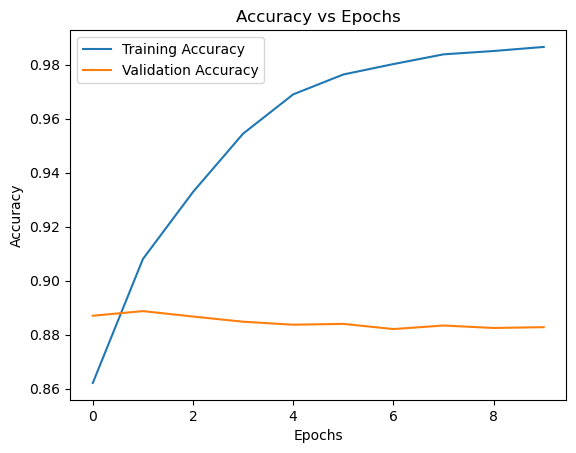

In [36]:
# =========================
# 10. PLOT GRAPH
# =========================

# Plot training vs validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [37]:
# =========================
# 12. FINAL EVALUATION
# =========================

# Evaluate model on test data
loss, accuracy = model.evaluate(X_test, y_test)

# Print final results
print("\nFinal Loss:", loss)
print("Final Accuracy:", accuracy)


311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8828 - loss: 0.5129

Final Loss: 0.5128579139709473
Final Accuracy: 0.8827975392341614
